In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/SCRC/kadid_split.zip"
extract_path = "/content/kadid_split"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level <= 1:
        print(f"{'  '*level}{os.path.basename(root) or root}: {len(files)} files")

kadid_split: 0 files
  kadid_split: 3 files


In [3]:
import os
for root, dirs, files in os.walk("/content/kadid_split"):
    print(root, "->", len(files), "files", dirs)

/content/kadid_split -> 0 files ['kadid_split']
/content/kadid_split/kadid_split -> 3 files ['val', 'test', 'train']
/content/kadid_split/kadid_split/val -> 780 files []
/content/kadid_split/kadid_split/test -> 845 files []
/content/kadid_split/kadid_split/train -> 3640 files []


In [1]:
import os, json, torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

DATA_ROOT = "/content/kadid_split/kadid_split"
LABEL_MAP = {"ACCEPTABLE": 0, "DEGRADED": 1, "DEFECTIVE": 2}

class QualityDataset(Dataset):
    def __init__(self, split, transform):
        self.root = os.path.join(DATA_ROOT, split)
        with open(os.path.join(DATA_ROOT, f"{split}_labels.json")) as f:
            self.records = json.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = Image.open(os.path.join(self.root, r["filename"])).convert("RGB")
        img = self.transform(img)
        label = LABEL_MAP[r["quality_label"]]
        return img, label

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = QualityDataset("train", train_tf)
val_ds = QualityDataset("val", eval_tf)
test_ds = QualityDataset("test", eval_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

train=3640 val=780 test=845


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss/total, correct/total

EPOCHS = 8
best_val_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/quality_model_best.pt")
        print(f"  -> new best model saved (val_acc={val_acc:.4f})")

print(f"Best val_acc: {best_val_acc:.4f}")

Using: cuda
Epoch 1/8 | train_loss=0.9592 train_acc=0.5022 | val_loss=0.8630 val_acc=0.5654
  -> new best model saved (val_acc=0.5654)
Epoch 2/8 | train_loss=0.6840 train_acc=0.6780 | val_loss=0.7194 val_acc=0.6295
  -> new best model saved (val_acc=0.6295)
Epoch 3/8 | train_loss=0.5497 train_acc=0.7596 | val_loss=0.7167 val_acc=0.6218
Epoch 4/8 | train_loss=0.4669 train_acc=0.7918 | val_loss=0.7207 val_acc=0.6295
Epoch 5/8 | train_loss=0.4406 train_acc=0.8088 | val_loss=0.7799 val_acc=0.6372
  -> new best model saved (val_acc=0.6372)
Epoch 6/8 | train_loss=0.4056 train_acc=0.8250 | val_loss=0.7644 val_acc=0.6487
  -> new best model saved (val_acc=0.6487)
Epoch 7/8 | train_loss=0.3823 train_acc=0.8374 | val_loss=0.8079 val_acc=0.6436
Epoch 8/8 | train_loss=0.3300 train_acc=0.8604 | val_loss=0.8289 val_acc=0.6577
  -> new best model saved (val_acc=0.6577)
Best val_acc: 0.6577


In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best checkpoint fresh (in case model in memory drifted)
eval_model = models.mobilenet_v2(weights=None)
eval_model.classifier[1] = nn.Linear(eval_model.last_channel, 3)
eval_model.load_state_dict(torch.load("/content/quality_model_best.pt"))
eval_model = eval_model.to(device)
eval_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = eval_model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

class_names = ["ACCEPTABLE", "DEGRADED", "DEFECTIVE"]
print("=== Test Set Performance ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))
print("Confusion Matrix (rows=true, cols=predicted):")
print(class_names)
print(confusion_matrix(all_labels, all_preds))

=== Test Set Performance ===
              precision    recall  f1-score   support

  ACCEPTABLE      0.685     0.333     0.448       222
    DEGRADED      0.530     0.685     0.598       305
   DEFECTIVE      0.776     0.836     0.805       318

    accuracy                          0.650       845
   macro avg      0.664     0.618     0.617       845
weighted avg      0.663     0.650     0.637       845

Confusion Matrix (rows=true, cols=predicted):
['ACCEPTABLE', 'DEGRADED', 'DEFECTIVE']
[[ 74 136  12]
 [ 31 209  65]
 [  3  49 266]]


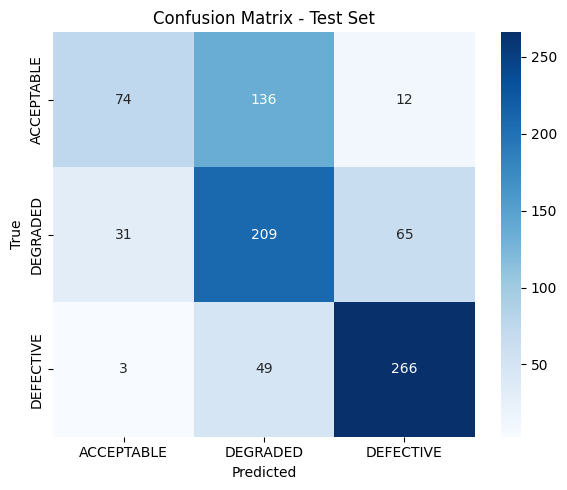

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = ["ACCEPTABLE", "DEGRADED", "DEFECTIVE"]
cm = confusion_matrix(all_labels, all_preds)

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

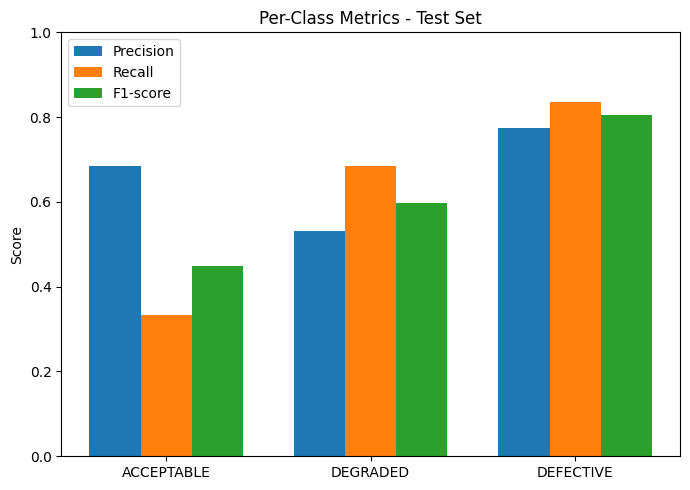

In [5]:
# Precision/Recall/F1 bar chart
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(7,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')
plt.xticks(x, class_names)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Per-Class Metrics - Test Set')
plt.legend()
plt.tight_layout()
plt.savefig('/content/metrics_barchart.png', dpi=150)
plt.show()

In [6]:
import zipfile, os

zip_path = "/content/drive/MyDrive/SCRC/demo_degraded.zip"
extract_path = "/content/demo_degraded"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

/content/demo_degraded -> 0 files
/content/demo_degraded/demo_degraded -> 41 files


In [7]:
import json
from PIL import Image
import torch

demo_dir = "/content/demo_degraded/demo_degraded"
with open(f"{demo_dir}/labels.json") as f:
    demo_labels = json.load(f)

LABEL_MAP_INV = {0: "ACCEPTABLE", 1: "DEGRADED", 2: "DEFECTIVE"}

results = []
eval_model.eval()
with torch.no_grad():
    for rec in demo_labels:
        img_path = f"{demo_dir}/{rec['filename']}"
        img = Image.open(img_path).convert("RGB")
        img_t = eval_tf(img).unsqueeze(0).to(device)
        output = eval_model(img_t)
        pred_idx = output.argmax(1).item()
        pred_label = LABEL_MAP_INV[pred_idx]
        true_label = rec["quality_label"]
        results.append({
            "filename": rec["filename"],
            "degradation_type": rec["degradation_type"],
            "true_label": true_label,
            "pred_label": pred_label,
            "correct": pred_label == true_label
        })

correct_count = sum(r["correct"] for r in results)
print(f"Smart-city demo set accuracy: {correct_count}/{len(results)} = {correct_count/len(results):.3f}")
print()
print(f"{'filename':<45} {'degradation':<15} {'true':<12} {'pred':<12} {'ok'}")
for r in results:
    print(f"{r['filename']:<45} {r['degradation_type']:<15} {r['true_label']:<12} {r['pred_label']:<12} {'✓' if r['correct'] else '✗'}")

Smart-city demo set accuracy: 14/40 = 0.350

filename                                      degradation     true         pred         ok
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d - Copy - Copy - Copy_clean.jpg none            ACCEPTABLE   DEGRADED     ✗
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d - Copy - Copy_blur_sev1.jpg blur            DEGRADED     DEGRADED     ✓
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d - Copy_overexposure_sev1.jpg overexposure    DEGRADED     DEGRADED     ✓
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d_underexposure_sev1.jpg underexposure   DEGRADED     DEGRADED     ✓
aguanambi-1000_png_jpg.rf.dc59d3c5df5d991c1475e5957ea9948c_clean.jpg none            ACCEPTABLE   DEGRADED     ✗
aguanambi-1000_png_jpg.rf.f425c626b206bb27a1b73fa7e38d6361_blur_sev3.jpg blur            DEFECTIVE    DEFECTIVE    ✓
aguanambi-1085_png_jpg.rf.60d1095729839f1644f21e2a31e55cec_corruption_sev1.jpg corruption      DEGRADED     DEG

In [8]:
import cv2
import numpy as np
from feature_extractor import extract_features

def fuse_prediction(cnn_label, cv_features):
    """
    Combines the CNN's prediction with classical CV flags to correct
    for domain-shift overconfidence (CNN trained on curated reference
    images tends to over-predict severity on real-world camera photos).

    Rule: count how many independent CV issues are actually triggered.
    - 0 CV flags  -> can't be worse than DEGRADED (likely ACCEPTABLE)
    - 1 CV flag   -> cap at DEGRADED unless CNN says DEFECTIVE with
                     a real corroborating flag
    - 2+ CV flags -> trust CNN's DEFECTIVE call
    """
    flags = [
        cv_features["is_blurry"],
        cv_features["is_underexposed"],
        cv_features["is_overexposed"],
        cv_features["is_noisy"],
        cv_features["is_likely_corrupt"],
    ]
    n_flags = sum(flags)

    if n_flags == 0:
        return "ACCEPTABLE"
    elif n_flags == 1:
        return "DEGRADED" if cnn_label == "DEFECTIVE" else cnn_label
    else:
        return cnn_label

# Re-run demo set with fused predictions
fused_results = []
with torch.no_grad():
    for rec in demo_labels:
        img_path = f"{demo_dir}/{rec['filename']}"
        img_bgr = cv2.imread(img_path)
        cv_feats = extract_features(img_bgr)

        pil_img = Image.open(img_path).convert("RGB")
        img_t = eval_tf(pil_img).unsqueeze(0).to(device)
        output = eval_model(img_t)
        cnn_label = LABEL_MAP_INV[output.argmax(1).item()]

        fused_label = fuse_prediction(cnn_label, cv_feats)
        true_label = rec["quality_label"]

        fused_results.append({
            "filename": rec["filename"],
            "true_label": true_label,
            "cnn_label": cnn_label,
            "fused_label": fused_label,
            "correct": fused_label == true_label
        })

correct_count = sum(r["correct"] for r in fused_results)
print(f"Fused accuracy: {correct_count}/{len(fused_results)} = {correct_count/len(fused_results):.3f}")
print()
for r in fused_results:
    print(f"{r['filename']:<45} true={r['true_label']:<12} cnn={r['cnn_label']:<12} fused={r['fused_label']:<12} {'✓' if r['correct'] else '✗'}")

Fused accuracy: 32/40 = 0.800

aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d - Copy - Copy - Copy_clean.jpg true=ACCEPTABLE   cnn=DEGRADED     fused=DEGRADED     ✗
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d - Copy - Copy_blur_sev1.jpg true=DEGRADED     cnn=DEGRADED     fused=DEGRADED     ✓
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d - Copy_overexposure_sev1.jpg true=DEGRADED     cnn=DEGRADED     fused=DEGRADED     ✓
aguanambi-1000_png_jpg.rf.0ab6f274892b9b370e6441886b2d7b9d_underexposure_sev1.jpg true=DEGRADED     cnn=DEGRADED     fused=DEGRADED     ✓
aguanambi-1000_png_jpg.rf.dc59d3c5df5d991c1475e5957ea9948c_clean.jpg true=ACCEPTABLE   cnn=DEGRADED     fused=ACCEPTABLE   ✓
aguanambi-1000_png_jpg.rf.f425c626b206bb27a1b73fa7e38d6361_blur_sev3.jpg true=DEFECTIVE    cnn=DEFECTIVE    fused=DEGRADED     ✗
aguanambi-1085_png_jpg.rf.60d1095729839f1644f21e2a31e55cec_corruption_sev1.jpg true=DEGRADED     cnn=DEGRADED     fused=DEGRADED     ✓
aguanambi